![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [196]:
import warnings
warnings.filterwarnings('ignore')

In [197]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import resample


In [198]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [199]:
# Celda 1.1
bikes.groupby('season').total.mean()
bikes.groupby('season').total.describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [200]:
# Celda 1.2
bikes.groupby('hour').total.mean()
bikes.groupby('hour').total.describe()

,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0


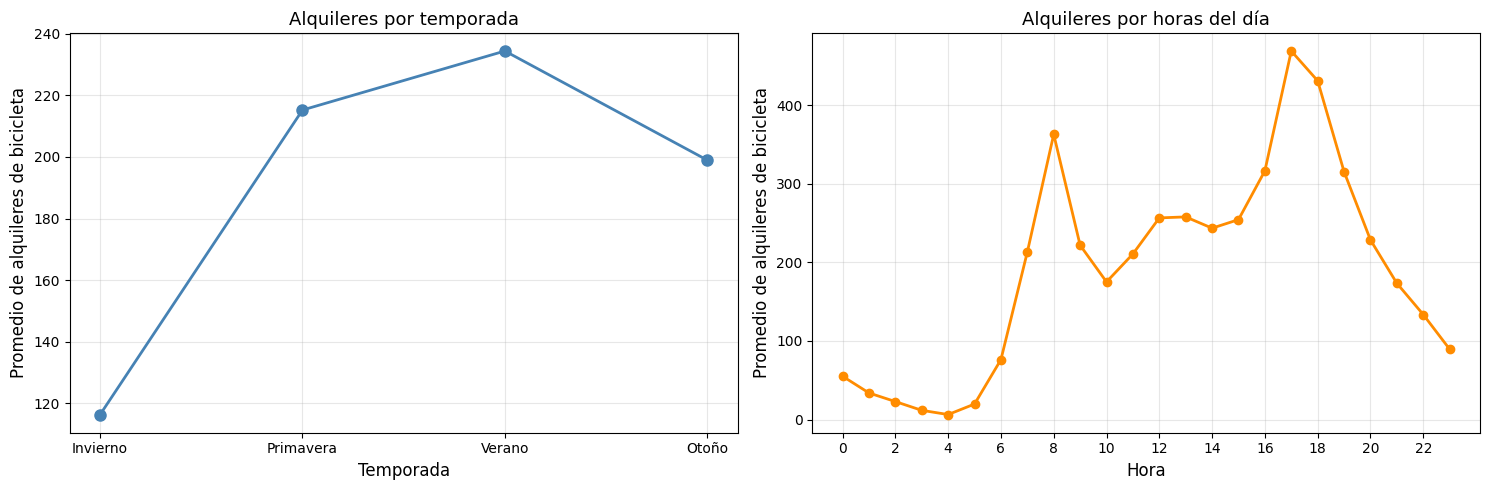

In [201]:
# Gráficas de media por season y hora
import matplotlib.pyplot as plt

media_por_season = bikes.groupby('season').total.mean()
media_por_hora = bikes.groupby('hour').total.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica de season
ax1.plot(media_por_season.index, media_por_season.values, marker='o', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('Temporada', fontsize=12)
ax1.set_ylabel('Promedio de alquileres de bicicleta', fontsize=12)
ax1.set_title('Alquileres por temporada', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(['Invierno', 'Primavera', 'Verano', 'Otoño'])

ax2.plot(media_por_hora.index, media_por_hora.values, marker='o', linewidth=2, markersize=6, color='darkorange')
ax2.set_xlabel('Hora', fontsize=12)
ax2.set_ylabel('Promedio de alquileres de bicicleta', fontsize=12)
ax2.set_title('Alquileres por horas del día', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

Existe un patrón diferencial entre la temporada y la hora del día, con el total del alquiler de bicicletas. En la temporada de verano (season=3) se observa un mayor número de alquileres. En contraste, en la temporada de invierno (season=1) el número de alquileres es significativamente menor. Con las horas podemos observar que durante las horas de la mañana entre 7-9  y en la tarde entre 4pm y 7pm se registra un aumento en los alquileres. Esto sugiere que el clima y la temperatura influyen en la demanda de bicicletas, siendo más favorable para el alquiler durante los meses más cálidos y en horarios específicos del día.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

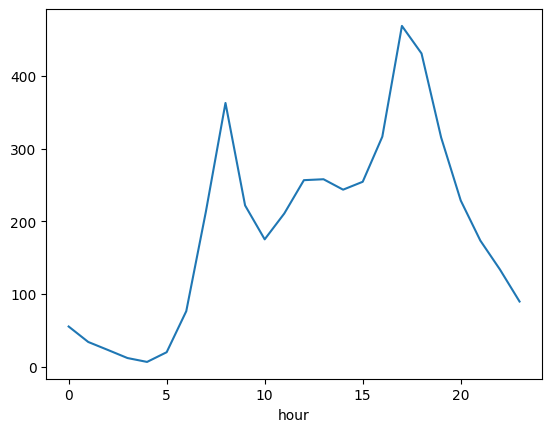

In [202]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

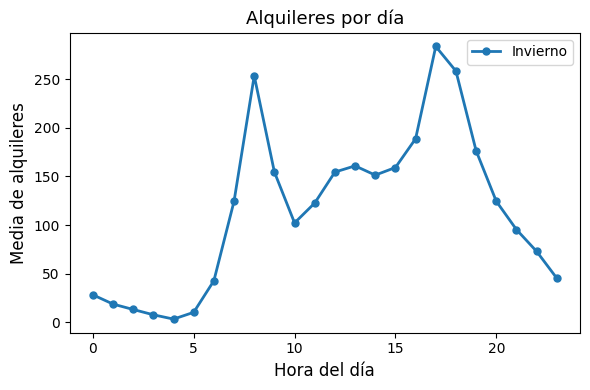

La gráfica de invierno muestra un patron de alquileres similar al promedio, en forma, no en cantidad.


In [203]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos
invierno = bikes[bikes['season'] == 1].groupby('hour').total.mean()

plt.figure(figsize=(6,  4))
plt.plot(invierno.index, invierno.values, marker='o', linewidth=2, markersize=5, label='Invierno')
   
plt.xlabel('Hora del día', fontsize=12)
plt.ylabel('Media de alquileres', fontsize=12)
plt.title('Alquileres por día', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print(f"La gráfica de invierno muestra un patron de alquileres similar al promedio, en forma, no en cantidad.")

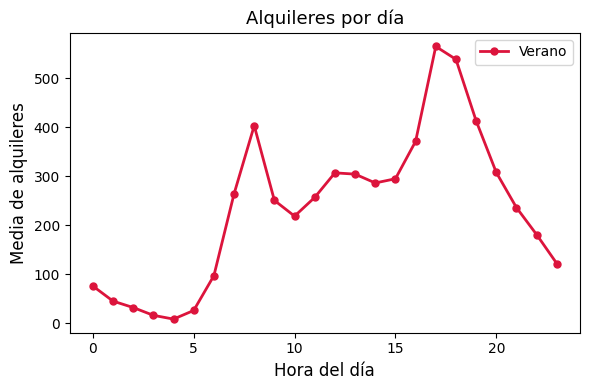

In [204]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
verano = bikes[bikes['season'] == 3].groupby('hour').total.mean()

plt.figure(figsize=(6,  4))
plt.plot(verano.index, verano.values, marker='o', linewidth=2, markersize=5, label='Verano', color='crimson')
   
plt.xlabel('Hora del día', fontsize=12)
plt.ylabel('Media de alquileres', fontsize=12)
plt.title('Alquileres por día', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

## La gráfica de verano muestra un patron de alquileres similar al promedio general, en forma, 
# no en cantidad.

### Hallazgos

Podemos observar que ambas temporadas cumplen con el mismo patrón de alquileres para cad hora del día, sin importar la temporada. Sin embargo, la diferencia sí se muestra en la cantidad de bicicletas alquiladas, ya que aunque los horarios mantienen un patrón similar, el número de alquileres varia significativamente entre las temporadas. La horas picos de alquileres sugieren que en ciertas franjas horarias, como las horas de la mañana y la tarde, hay una mayor demanda de bicicletas, lo que podría estar relacionado con los desplazamientos diarios de las personas hacia el trabajo o la escuela. En general, el análisis sugiere que tanto la temporada como la hora del día son factores importantes que influyen en el número de bicicletas alquiladas.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [205]:
# Celda 3 - Regresión lineal

X = bikes[['season', 'hour']]
y = bikes['total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


encoder = OneHotEncoder(sparse_output=False, drop=None)
X_train_encoded = encoder.fit_transform(X_train[['season']])
X_test_encoded = encoder.transform(X_test[['season']])

X_train_final = np.column_stack([X_train_encoded, X_train['hour'].values])
X_test_final = np.column_stack([X_test_encoded, X_test['hour'].values])

modelo = LinearRegression()
modelo.fit(X_train_final, y_train)
y_pred_train = modelo.predict(X_train_final)
y_pred_test = modelo.predict(X_test_final)


r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))


print('------------------------------------------')
print('    Métricas de desempeño del modelo    ')
print('------------------------------------------')
print(f'R² Entrenamiento: {r2_train:.4f}')
print(f'R² Test: {r2_test:.4f}')
print(f'RMSE Entrenamiento: {rmse_train:.2f}')
print(f'RMSE Test: {rmse_test:.2f}')

# Coeficientes
coeficientes = modelo.coef_
intercepto = modelo.intercept_

print('------------------------------------------')
print('   Coeficientes del modelo    ')
print('------------------------------------------')

print(f'Intercepto: {intercepto:.4f}')
print(f'Season 1 (Invierno): {coeficientes[0]:.4f}')
print(f'Season 2 (Primavera): {coeficientes[1]:.4f}')
print(f'Season 3 (Verano): {coeficientes[2]:.4f}')
print(f'Season 4 (Otoño): {coeficientes[3]:.4f}')
print(f'Hour: {coeficientes[4]:.4f}')

print('------------------------------------------')
print('    Modelos específicos por temporada  ')
print('------------------------------------------')

print(f'Modelo Invierno = {intercepto:.2f} + {coeficientes[0]:.2f}*1 + hora*{coeficientes[4]:.2f} = {intercepto + coeficientes[0]:.2f} + hora*{coeficientes[4]:.2f}')
print(f'Modelo Primavera = {intercepto:.2f} + {coeficientes[1]:.2f}*1 + hora*{coeficientes[4]:.2f} = {intercepto + coeficientes[1]:.2f} + hora*{coeficientes[4]:.2f}')
print(f'Modelo Verano = {intercepto:.2f} + {coeficientes[2]:.2f}*1 + hora*{coeficientes[4]:.2f} = {intercepto + coeficientes[2]:.2f} + hora*{coeficientes[4]:.2f}')
print(f'Modelo Otoño = {intercepto:.2f} + {coeficientes[3]:.2f}*1 + hora*{coeficientes[4]:.2f} = {intercepto + coeficientes[3]:.2f} + hora*{coeficientes[4]:.2f}')


------------------------------------------
    Métricas de desempeño del modelo    
------------------------------------------
R² Entrenamiento: 0.2216
R² Test: 0.2302
RMSE Entrenamiento: 159.69
RMSE Test: 159.40
------------------------------------------
   Coeficientes del modelo    
------------------------------------------
Intercepto: 69.1049
Season 1 (Invierno): -75.0245
Season 2 (Primavera): 24.0822
Season 3 (Verano): 41.0219
Season 4 (Otoño): 9.9203
Hour: 10.5696
------------------------------------------
    Modelos específicos por temporada  
------------------------------------------
Modelo Invierno = 69.10 + -75.02*1 + hora*10.57 = -5.92 + hora*10.57
Modelo Primavera = 69.10 + 24.08*1 + hora*10.57 = 93.19 + hora*10.57
Modelo Verano = 69.10 + 41.02*1 + hora*10.57 = 110.13 + hora*10.57
Modelo Otoño = 69.10 + 9.92*1 + hora*10.57 = 79.03 + hora*10.57


##### Interpretación del desempeño del modelo

El R2 de 0.23 es bastante bajo. Esto significa que el modelo solo explica el 23% de lo que sucede con los alquileres de bicicletas. A su vez, con un RMSE de 159.40, el modelo se equivoca en sus predicciones. Estos resultados indican que la regresión lineal no es suficiente para entender este problema.

##### Interpretación de los coeficientes

Los coeficientes muestran algo interesante, aunque la hora tiene un efecto positivo no es coherente con el comportamiento mostrado por hora en las gráficas(podemos ver que la hora tiene picos y bajadas a lo largo del día no un incremento lineal, independientemente de la temporada). Sin embargo los coeficientes de las temporadas se comportan de manera consistente, ya que el invierno tiene coeficientes negativos, mientras que las otras temporadas tienen coeficientes positivos, que se reflejan en la realidad de que en invierno hay menos alquileres que en cualquier otra temporada. Esto sugiere que la relación entre estas variables es más compleja de lo que un modelo lineal puede captar y el modelo no se acerca a la realidad de las variables.

#### Limitaciones de la regresión lineal<

El modelo lineal funciona como una línea recta: asume que las variables siempre se comportan de la misma manera. Pero en realidad, la hora del día no es igual en cualquier temporada. El modelo no entiende esta diferencia porque trata la hora y la temporada como si fueran independientes, cuando en realidad se influyen mutuamente.

En conclusión, la regresión lineal es demasiado simple para este problema. El bajo R2 y los errores altos nos dicen que se está perdiendo información importante. Necesitamos un modelo más flexible que pueda captar cómo la hora y la temporada interactúan entre sí, y que reconozca los patrones no lineales que vemos en los datos.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [206]:
# Celda 4 - Árbol de decisión

X = bikes[['season', 'hour']]
y = bikes['total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

encoder = OneHotEncoder(sparse_output=False, drop=None)
X_train_encoded = encoder.fit_transform(X_train[['season']])
X_train_final = np.column_stack([X_train_encoded, X_train['hour'].values])

X_train_final_df = pd.DataFrame(X_train_final, columns=['season_1', 'season_2', 'season_3', 'season_4', 'hour'])
X_train_final_df = X_train_final_df.reset_index(drop=True)
y_train_reset = pd.Series(y_train.values, index=X_train_final_df.index)


def mse(y):
    if len(y) == 0:
        return 0
    return np.sum((y - y.mean()) ** 2) / len(y)

def variance_reduction(y_parent, y_left, y_right):
    n = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)
    
    if n_left == 0 or n_right == 0:
        return 0
    
    var_parent = mse(y_parent)
    var_left = mse(y_left)
    var_right = mse(y_right)
    
    # Ganancia
    ganancia = var_parent - (n_left/n * var_left + n_right/n * var_right)
    return ganancia

def find_best_split(X, y):
    best_feature = None
    best_threshold = None
    best_gain = -1
    
    for j in range(X.shape[1]):
        col = X.iloc[:, j]
        
        for percentil in [10, 20, 30, 40, 50, 60, 70, 80, 90]:
            threshold = col.quantile(percentil / 100)
            
            izquierda = col < threshold
            y_izq = y[izquierda]
            y_der = y[~izquierda]
            
            if len(y_izq) > 0 and len(y_der) > 0:
                ganancia = variance_reduction(y, y_izq, y_der)
                
                if ganancia > best_gain:
                    best_gain = ganancia
                    best_feature = j
                    best_threshold = threshold
    
    return best_feature, best_threshold, best_gain


max_depth = 8
min_samples = 17
depth=0
node_id = [0]
tree_splits = []

def build_tree_recursive(X, y, depth, max_depth, min_samples):
    node_id[0] += 1
    current_id = node_id[0]
    
    n_samples = len(y)
    y_mean = y.mean()
    
    # Criterios de parada
    if depth >= max_depth or n_samples < min_samples or len(y.unique()) == 1:
        print(f"{'  ' * depth}Nodo {current_id} [HOJA]")
        print(f"{'  ' * depth}└─ Predicción: {y_mean:.2f} | Muestras: {n_samples}")
        return {
            'id': current_id, 'is_leaf': True, 'prediction': y_mean, 
            'samples': n_samples, 'variance': mse(y)
        }
    
    best_feature, best_threshold, best_gain = find_best_split(X, y)
    
    if best_feature is None or best_gain < 0:
        return {
            'id': current_id, 'is_leaf': True, 'prediction': y_mean, 
            'samples': n_samples, 'variance': mse(y)}
    
    feature_name = X.columns[best_feature]
    n_left = (X.iloc[:, best_feature] < best_threshold).sum()
    n_right = n_samples - n_left
    
    tree_splits.append({
        'nodo': current_id,
        'variable': feature_name,
        'corte': best_threshold,
        'ganancia': best_gain,
        'muestras_izq': n_left,
        'muestras_der': n_right})
    
    # Dividir datos y construir arboles
    mask = X.iloc[:, best_feature] < best_threshold
    X_left, X_right = X[mask], X[~mask]
    y_left, y_right = y[mask], y[~mask]
    
    left_node = build_tree_recursive(X_left, y_left, depth+1, max_depth, min_samples)
    right_node = build_tree_recursive(X_right, y_right, depth+1, max_depth, min_samples)
    
    return {
        'id': current_id, 'is_leaf': False,
        'feature': best_feature, 'feature_name': feature_name,
        'split': best_threshold, 'gain': best_gain, 'samples': n_samples,
        'left': left_node, 'right': right_node}

tree = build_tree_recursive(X_train_final_df, y_train_reset, depth=0, max_depth=max_depth, min_samples=min_samples)

# Función para hacer predicciones usando el árbol manual
def predict_with_tree(node, x):
    if node['is_leaf']:
        return node['prediction']
    feature_idx = node['feature']
    threshold = node['split']
    if x[feature_idx] < threshold:
        return predict_with_tree(node['left'], x)
    else:
        return predict_with_tree(node['right'], x)

# Predicciones
y_pred_test_tree = np.array([predict_with_tree(tree, X_test_final[i]) for i in range(len(X_test_final))])

# Métricas 
r2_test_tree_manual = r2_score(y_test, y_pred_test_tree)
rmse_test_tree_manual = np.sqrt(mean_squared_error(y_test, y_pred_test_tree))

print("   Evaluación del árbol    ")
print("------------------------------------------")
print(f'R2 Test: {r2_test_tree_manual:.4f}')
print(f'RMSE Test: {rmse_test_tree_manual:.2f}')


                Nodo 16 [HOJA]
                └─ Predicción: 34.12 | Muestras: 92
                Nodo 17 [HOJA]
                └─ Predicción: 33.19 | Muestras: 90
                Nodo 21 [HOJA]
                └─ Predicción: 24.17 | Muestras: 94
                Nodo 22 [HOJA]
                └─ Predicción: 23.97 | Muestras: 89
                Nodo 31 [HOJA]
                └─ Predicción: 11.49 | Muestras: 177
                Nodo 32 [HOJA]
                └─ Predicción: 8.09 | Muestras: 74
                Nodo 36 [HOJA]
                └─ Predicción: 7.78 | Muestras: 178
                Nodo 37 [HOJA]
                └─ Predicción: 6.74 | Muestras: 95
                Nodo 42 [HOJA]
                └─ Predicción: 22.88 | Muestras: 96
                Nodo 43 [HOJA]
                └─ Predicción: 20.02 | Muestras: 89
                Nodo 60 [HOJA]
                └─ Predicción: 228.72 | Muestras: 97
                Nodo 61 [HOJA]
                └─ Predicción: 216.59 | Muestras: 83
   

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [207]:
# Celda 5 - Árbol de decisión
max_depth_range = range(1, 21)
rmse_scores = []

modelo_arbol_final = DecisionTreeRegressor(max_depth=8, criterion='squared_error', random_state=1)
modelo_arbol_final.fit(X_train_final, y_train)

y_pred_train_tree = modelo_arbol_final.predict(X_train_final)
y_pred_test_tree = modelo_arbol_final.predict(X_test_final)

r2_train_tree = r2_score(y_train, y_pred_train_tree)
r2_test_tree = r2_score(y_test, y_pred_test_tree)
rmse_test_tree = np.sqrt(mean_squared_error(y_test, y_pred_test_tree))


print("   Evaluación del árbol    ")
print("------------------------------------------")
print(f'R2 Entrenamiento: {r2_train_tree:.4f}')
print(f'R2 Test: {r2_test_tree:.4f}')
print(f'RMSE Test: {rmse_test_tree:.2f}')



   Evaluación del árbol    
------------------------------------------
R2 Entrenamiento: 0.6137
R2 Test: 0.5919
RMSE Test: 116.07


In [208]:
#Resultados de ambos modelos 
print(f'{"Modelo":<20} {"R2 Test":<15} {"RMSE Test":<15}')
print('-'*50)
print(f'{"Árbol manual":<20} {r2_test_tree_manual:<15.4f} {rmse_test_tree_manual:<15.4f}')
print(f'{"Árbol con sklearn":<20} {r2_test_tree:<15.4f} {rmse_test_tree:<15.4f}')

Modelo               R2 Test         RMSE Test      
--------------------------------------------------
Árbol manual         0.5919          116.0675       
Árbol con sklearn    0.5919          116.0675       


### Comparación de árboles de decisión

En este caso ambos modelos de áboles tienen desempeño igual en test y en R2 y RMSE, lo que sugiere que no importan si las decisiones son manuales o automaticas, ambos logran capturar la esencia de los patrones de los datos a la misma profundidad. Sin embargo, es importante destacar que el árbol de decisión con sklearn tiene la ventaja de ser más eficiente y menos propenso a errores humanos en el árbol, lo que puede ser especialmente beneficioso en conjuntos de datos más complejos. En resumen, ambos enfoques pueden ser efectivos, pero el uso de una librería como sklearn puede ofrecer una mayor facilidad y precisión en la construcción de modelos.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [209]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [210]:
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [211]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [212]:
# Celda 6 - Árbol de decisión y Regresión logística

dt_model = DecisionTreeClassifier(random_state=1)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)


lr_model = LogisticRegression(random_state=1)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)


print(f'{"Modelo":<20} {"Accuracy":<15} {"F1-Score":<15}')
print('-'*50)
print(f'{"Árbol Decisión":<20} {accuracy_dt:<15.4f} {f1_dt:<15.4f}')
print(f'{"Regresión Logística":<20} {accuracy_lr:<15.4f} {f1_lr:<15.4f}')

Modelo               Accuracy        F1-Score       
--------------------------------------------------
Árbol Decisión       0.5520          0.5544         
Regresión Logística  0.6147          0.6121         


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [213]:
# Celda 7 - Ensamble

## Grupo 1: 100 arboles con max_depth=3 y random_state diferente para cada uno 
predictions_group1 = []

for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    dt_boot = DecisionTreeClassifier(max_depth=3, random_state=i)
    dt_boot.fit(X_boot, y_boot)
    y_pred_boot = dt_boot.predict(X_test)
    predictions_group1.append(y_pred_boot)

predictions_group1 = np.array(predictions_group1)
y_pred_group1_ensemble = (predictions_group1.mean(axis=0) >= 0.5).astype(int)
accuracy_group1 = accuracy_score(y_test, y_pred_group1_ensemble)
f1_group1 = f1_score(y_test, y_pred_group1_ensemble)


# Grupo 2: 100 árboles con min_samples_leaf=10 y random_state diferente para cada uno

predictions_group2 = []

for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, random_state=100+i)
    dt_boot = DecisionTreeClassifier(min_samples_leaf=10, random_state=100+i)
    dt_boot.fit(X_boot, y_boot)
    y_pred_boot = dt_boot.predict(X_test)
    predictions_group2.append(y_pred_boot)
predictions_group2 = np.array(predictions_group2)

y_pred_group2_ensemble = (predictions_group2.mean(axis=0) >= 0.5).astype(int)
accuracy_group2 = accuracy_score(y_test, y_pred_group2_ensemble)
f1_group2 = f1_score(y_test, y_pred_group2_ensemble)


# Grupo 3: 100 regresiones logísticas y random_state diferente para cada uno
predictions_group3 = []

for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, random_state=200+i)
    lr_boot = LogisticRegression(random_state=200+i, max_iter=1000)
    lr_boot.fit(X_boot, y_boot)
    y_pred_boot = lr_boot.predict(X_test)
    predictions_group3.append(y_pred_boot)

predictions_group3 = np.array(predictions_group3)

y_pred_group3_ensemble = (predictions_group3.mean(axis=0) >= 0.5).astype(int)
accuracy_group3 = accuracy_score(y_test, y_pred_group3_ensemble)
f1_group3 = f1_score(y_test, y_pred_group3_ensemble)

#Ensamble final con las 300 predicciones de los tres grupos
all_predictions = np.vstack([predictions_group1, predictions_group2, predictions_group3])

# Votación mayoritaria sobre las 300 predicciones
y_pred_ensamble_300 = (all_predictions.sum(axis=0) >= all_predictions.shape[0] / 2).astype(int)

accuracy_ensamble_300 = accuracy_score(y_test, y_pred_ensamble_300)
f1_ensamble_300 = f1_score(y_test, y_pred_ensamble_300)

print(f'{"Grupo":<30}{"Accuracy":<14} {"F1-Score":<14}')
print('-'*70)
print(f'{"Grupo 1 (max_depth=3)":<30} {accuracy_group1:<14.4f} {f1_group1:<14.4f}')
print(f'{"Grupo 2 (min_samples_leaf=10)":<30} {accuracy_group2:<14.4f} {f1_group2:<14.4f}')
print(f'{"Grupo 3 (LogisticRegression)":<30} {accuracy_group3:<14.4f} {f1_group3:<14.4f}')
print(f'{"Ensamble 300 modelos":<30} {accuracy_ensamble_300:<14.4f} {f1_ensamble_300:<14.4f}')


Grupo                         Accuracy       F1-Score      
----------------------------------------------------------------------
Grupo 1 (max_depth=3)          0.6520         0.6468        
Grupo 2 (min_samples_leaf=10)  0.6540         0.6481        
Grupo 3 (LogisticRegression)   0.6167         0.6043        
Ensamble 300 modelos           0.6480         0.6379        


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [214]:
# Celda 8 - 

## Grupo 1: 100 arboles con max_depth=3 y random_state diferente para cada uno 
predictions_group1_weighted = []
weights_group1 = []

for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    dt_boot = DecisionTreeClassifier(max_depth=3, random_state=i)
    dt_boot.fit(X_boot, y_boot)

    y_pred_boot_train = dt_boot.predict(X_boot)
    accuracy_boot = accuracy_score(y_boot, y_pred_boot_train)

    y_pred_boot = dt_boot.predict(X_test)
    predictions_group1_weighted.append(y_pred_boot)
    weights_group1.append(accuracy_boot)

predictions_group1_weighted = np.array(predictions_group1_weighted)
weights_group1 = np.array(weights_group1)

# Calcular promedio ponderado
weighted_avg_group1 = (predictions_group1_weighted * weights_group1[:, np.newaxis]).sum(axis=0) / weights_group1.sum()
y_pred_group1_weighted = (weighted_avg_group1 >= 0.5).astype(int)

accuracy_group1_weighted = accuracy_score(y_test, y_pred_group1_weighted)
f1_group1_weighted = f1_score(y_test, y_pred_group1_weighted)

# Grupo 2: 100 árboles con min_samples_leaf=10 y random_state diferente para cada uno

predictions_group2_weighted = []
weights_group2 = []

for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, random_state=100+i)
    dt_boot = DecisionTreeClassifier(min_samples_leaf=10, random_state=100+i)
    dt_boot.fit(X_boot, y_boot)
    # Calcular los pesos con el train 
    y_pred_boot_train = dt_boot.predict(X_boot)
    accuracy_boot = accuracy_score(y_boot, y_pred_boot_train)
    # Predecir en test
    y_pred_boot = dt_boot.predict(X_test)
    predictions_group2_weighted.append(y_pred_boot)
    weights_group2.append(accuracy_boot)

predictions_group2_weighted = np.array(predictions_group2_weighted)
weights_group2 = np.array(weights_group2)

# Calcular promedio ponderado
weighted_avg_group2 = (predictions_group2_weighted * weights_group2[:, np.newaxis]).sum(axis=0) / weights_group2.sum()
y_pred_group2_weighted = (weighted_avg_group2 >= 0.5).astype(int)

accuracy_group2_weighted = accuracy_score(y_test, y_pred_group2_weighted)
f1_group2_weighted = f1_score(y_test, y_pred_group2_weighted)

# Grupo 3: 100 regresiones logísticas y random_state diferente para cada uno

predictions_group3_weighted = []
weights_group3 = []

for i in range(100):
    X_boot, y_boot = resample(X_train, y_train, random_state=200+i)
    lr_boot = LogisticRegression(random_state=200+i, max_iter=1000)
    lr_boot.fit(X_boot, y_boot)
    # Calcular los pesos con el train
    y_pred_boot_train = lr_boot.predict(X_boot)
    accuracy_boot = accuracy_score(y_boot, y_pred_boot_train)
    # Predecir en test 
    y_pred_boot = lr_boot.predict(X_test)
    predictions_group3_weighted.append(y_pred_boot)
    weights_group3.append(accuracy_boot)

predictions_group3_weighted = np.array(predictions_group3_weighted)
weights_group3 = np.array(weights_group3)

# Calcular promedio ponderado
weighted_avg_group3 = (predictions_group3_weighted * weights_group3[:, np.newaxis]).sum(axis=0) / weights_group3.sum()
y_pred_group3_weighted = (weighted_avg_group3 >= 0.5).astype(int)

accuracy_group3_weighted = accuracy_score(y_test, y_pred_group3_weighted)
f1_group3_weighted = f1_score(y_test, y_pred_group3_weighted)


# Combinar predicciones y pesos de los 300 modelos para el ensamble 

all_predictions_weighted = np.vstack([predictions_group1_weighted, predictions_group2_weighted, predictions_group3_weighted])
all_weights = np.concatenate([weights_group1, weights_group2, weights_group3])

# Calcular peso promedio de los 300 modelos 
weighted_avg_final = (all_predictions_weighted * all_weights[:, np.newaxis]).sum(axis=0) / all_weights.sum()
y_pred_ensamble_300_weighted = (weighted_avg_final >= 0.5).astype(int)

accuracy_ensamble_300_weighted = accuracy_score(y_test, y_pred_ensamble_300_weighted)
f1_ensamble_300_weighted = f1_score(y_test, y_pred_ensamble_300_weighted)


print(f'{"Grupo":<30} {"Peso":<20} {"Accuracy":<14} {"F1-Score":<14}')
print('-'*78)
print(f'{"Grupo 1 (max_depth=3)":<30} {weights_group1.mean():<20.4f} {accuracy_group1_weighted:<15.4f} {f1_group1_weighted:<15.4f}')
print(f'{"Grupo 2 (min_samples_leaf=10)":<30} {weights_group2.mean():<20.4f} {accuracy_group2_weighted:<15.4f} {f1_group2_weighted:<15.4f}')
print(f'{"Grupo 3 (LogisticRegression)":<30} {weights_group3.mean():<20.4f} {accuracy_group3_weighted:<15.4f} {f1_group3_weighted:<15.4f}')
print(f'{"Ensamble 300 modelos":<30} {all_weights.mean():<20.4f} {accuracy_ensamble_300_weighted:<15.4f} {f1_ensamble_300_weighted:<15.4f}')


Grupo                          Peso                 Accuracy       F1-Score      
------------------------------------------------------------------------------
Grupo 1 (max_depth=3)          0.6498               0.6513          0.6454         
Grupo 2 (min_samples_leaf=10)  0.8669               0.6520          0.6434         
Grupo 3 (LogisticRegression)   0.6255               0.6167          0.6043         
Ensamble 300 modelos           0.7140               0.6480          0.6369         


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [215]:
# Celda 9 - Comparación 

# Tabla de Accuracy
print(f"{'Modelo':<35} {'Votación Mayoritaria':<22} {'Votación Ponderada':<22}")
print(f"{'':35} {'Accuracy':<22} {'Accuracy':<22}")
print("-"*80)
print(f"{'Grupo 1 (max_depth=3)':<35} {accuracy_group1:<22.4f} {accuracy_group1_weighted:<22.4f}")
print(f"{'Grupo 2 (min_samples_leaf=10)':<35} {accuracy_group2:<22.4f} {accuracy_group2_weighted:<22.4f}")
print(f"{'Grupo 3 (LogisticRegression)':<35} {accuracy_group3:<22.4f} {accuracy_group3_weighted:<22.4f}")
print("-"*80)
print(f"{'Ensamble 300 modelos':<35} {accuracy_ensamble_300:<22.4f} {accuracy_ensamble_300_weighted:<22.4f}")
print("\n")
# Tabla de F1-Score
print(f"{'Modelo':<35} {'Votación Mayoritaria':<22} {'Votación Ponderada':<22}")
print(f"{'':35} {'F1-Score':<22} {'F1-Score':<22}")
print("-"*80)
print(f"{'Grupo 1 (max_depth=3)':<35} {f1_group1:<22.4f} {f1_group1_weighted:<22.4f}")
print(f"{'Grupo 2 (min_samples_leaf=10)':<35} {f1_group2:<22.4f} {f1_group2_weighted:<22.4f}")
print(f"{'Grupo 3 (LogisticRegression)':<35} {f1_group3:<22.4f} {f1_group3_weighted:<22.4f}")
print("-"*80)
print(f"{'Ensamble 300 modelos':<35} {f1_ensamble_300:<22.4f} {f1_ensamble_300_weighted:<22.4f}")


Modelo                              Votación Mayoritaria   Votación Ponderada    
                                    Accuracy               Accuracy              
--------------------------------------------------------------------------------
Grupo 1 (max_depth=3)               0.6520                 0.6513                
Grupo 2 (min_samples_leaf=10)       0.6540                 0.6520                
Grupo 3 (LogisticRegression)        0.6167                 0.6167                
--------------------------------------------------------------------------------
Ensamble 300 modelos                0.6480                 0.6480                


Modelo                              Votación Mayoritaria   Votación Ponderada    
                                    F1-Score               F1-Score              
--------------------------------------------------------------------------------
Grupo 1 (max_depth=3)               0.6468                 0.6454                
Grupo 2 (min_samp

### Análisis de resultados

En este caso, dado que el desempeño de cada modelo es similar y no se ve mucha diferencia entre la votación mayoritaria y la votación ponderada, la votación mayoritaria es una buena opción, ya que no hay modelos que dominen a los demás; Pero si tuviéramos modelos con desempeños muy distintos, la votación ponderada podría arrojar mejores resultados.

### Ventajas

• **Votación mayoritaria:** es más sencilla de entender, no requiere la asignación de pesos. Funciona bien cuando los modelos tienen desempeños similares.

• **Votación ponderada:** tiene en cuenta el desempeño de cada modelo, lo que puede mejorar la precisión del ensamble. Es útil cuando los modelos tienen desempeños muy distintos, ya que permite dar más peso a los modelos con mejor desempeño.

### Desventajas

• **Votación mayoritaria:** no tiene en cuenta el desempeño de cada modelo, ya que si mejoramos los modelos individuales, el ensamble no necesariamente mejora.

• **Votación ponderada:** requiere calcular y asignar pesos a cada modelo, lo que puede complicar la implementación y el entendimiento del ensamble. Además, como los pesos de los modelos se calculan en train, a la hora de probar en test puede que un modelo con buen desempeño en train no tenga el mismo desempeño en test y afecte la precisión del ensamble.
